# Supervised Audio Classification Model
This notebook trains a supervised Machine Learning model (Random Forest) on the separated audio clips.
Since we only have ~100 data points, extracting MFCC features and using a Random Forest is highly effective and avoids overfitting.

In [8]:
%pip install -q scikit-learn librosa pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [9]:
from pathlib import Path
import librosa
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Feature Extraction (MFCCs)
We will extract Mel-Frequency Cepstral Coefficients (MFCCs) which compactly represent the audio's frequency envelope over time.

In [10]:
def extract_mfcc(file_path, n_mfcc=40):
    try:
        y, sr = librosa.load(file_path, sr=22050)
        if len(y) == 0:
            return None
        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        # Take the mean across the time axis
        mfccs_scaled = np.mean(mfccs.T, axis=0)
        return mfccs_scaled
    except Exception as e:
        print(f"Error parsing {file_path}: {e}")
        return None

## 2. Load Data and Labels
We will simulate loading labels. *Replace this logic with your actual labeling method* (e.g., reading from a CSV or checking folder names).
For demonstration, we assume all files in `Data/Output` are "gunshots" (Label 1), and files in another folder are "noise" (Label 0).

In [11]:
def resolve_data_root():
    current = Path.cwd().resolve()
    expected_subdirs = ('edge-collected-gunshot-audio', 'gun', 'audio', 'sound')
    best_data_dir = None
    best_score = -1
    best_depth = 10**9

    for candidate in [current, *current.parents]:
        data_dir = candidate / 'Data'
        if not data_dir.exists():
            continue
        score = sum((data_dir / subdir).exists() for subdir in expected_subdirs)
        depth = len(data_dir.parts)
        if score > best_score or (score == best_score and depth < best_depth):
            best_data_dir = data_dir
            best_score = score
            best_depth = depth

    if best_data_dir is None:
        raise FileNotFoundError("Could not locate a valid Data folder.")

    return best_data_dir, best_score

BASE_DIR, DATA_MATCH_SCORE = resolve_data_root()
PROJECT_ROOT = BASE_DIR.parent
EDGE_ROOT = BASE_DIR / 'edge-collected-gunshot-audio'
EDGE_NESTED_ROOT = EDGE_ROOT / 'edge-collected-gunshot-audio'
EDGE_DATASET_ROOT = EDGE_NESTED_ROOT if EDGE_NESTED_ROOT.exists() else EDGE_ROOT

CLASS_1_DIRS = [BASE_DIR / 'gun', EDGE_DATASET_ROOT]
CLASS_0_DIRS = [BASE_DIR / 'audio', BASE_DIR / 'sound']

audio_files = []
labels = []

# Label 1: gun + edge-collected
for class1_dir in CLASS_1_DIRS:
    if class1_dir.exists():
        for wav_file in class1_dir.rglob('*.wav'):
            if '__MACOSX' in str(wav_file) or wav_file.name.startswith('._'):
                continue
            audio_files.append(str(wav_file))
            labels.append(1)
    else:
        print(f"[WARN] Missing class 1 directory: {class1_dir}")

# Label 0: audio + sound
for class0_dir in CLASS_0_DIRS:
    if class0_dir.exists():
        for wav_file in class0_dir.rglob('*.wav'):
            if '__MACOSX' in str(wav_file) or wav_file.name.startswith('._'):
                continue
            audio_files.append(str(wav_file))
            labels.append(0)
    else:
        print(f"[WARN] Missing class 0 directory: {class0_dir}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Data root: {BASE_DIR} (match score: {DATA_MATCH_SCORE}/4)")
print(f"Found {len(audio_files)} audio files.")
print(f"Class distribution: {pd.Series(labels).value_counts().sort_index().to_dict()}")


Project root: C:\Desktop\Data-Cleaner
Data root: C:\Desktop\Data-Cleaner\Data (match score: 4/4)
Found 10368 audio files.
Class distribution: {0: 6230, 1: 4138}


In [12]:
features = []
valid_labels = []

print("Extracting features. This may take a minute...")
for f, label in zip(audio_files, labels):
    data = extract_mfcc(f)
    if data is not None:
        features.append(data)
        valid_labels.append(label)

X = np.array(features)
y = np.array(valid_labels)

print(f"Feature matrix shape: {X.shape}")
print(f"Labels distribution: {pd.Series(y).value_counts().to_dict()}")

Extracting features. This may take a minute...
Feature matrix shape: (10368, 40)
Labels distribution: {0: 6230, 1: 4138}


## 3. Train the Model

In [13]:
# Split 80/20 for train/test
if len(X) > 5:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y if len(set(y)) > 1 else None)
    
    # Initialize and Train Random Forest
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    print("Model training complete!")
else:
    print("Not enough data to train. Please ensure you have extracted audio data.")

Model training complete!


## 4. Evaluation

Classification Report:

              precision    recall  f1-score   support

       Noise       0.99      1.00      0.99      1246
     Gunshot       0.99      0.98      0.99       828

    accuracy                           0.99      2074
   macro avg       0.99      0.99      0.99      2074
weighted avg       0.99      0.99      0.99      2074



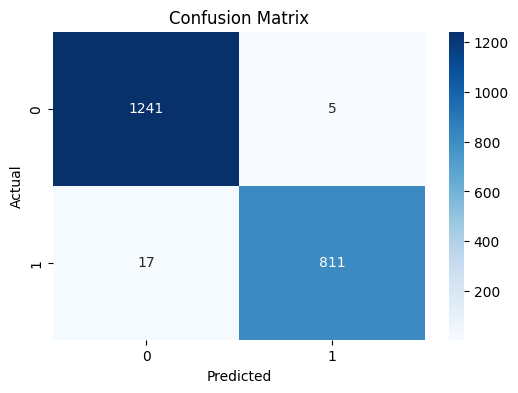

In [14]:
if len(X) > 5:
    predictions = rf_model.predict(X_test)
    
    # If you only have ONE class of data right now (e.g., everything is a gunshot), 
    # precision/recall metrics won't mean much until you add negative samples!
    print("Classification Report:\n")
    try:
        print(classification_report(y_test, predictions, target_names=["Noise", "Gunshot"] if len(set(y)) > 1 else ["Gunshot"]))
    except ValueError:
        print(classification_report(y_test, predictions))
        
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()